In [1]:
!pip install wfdb matplotlib numpy scipy

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.5 MB 4.6 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.5 MB 4.2 MB/s eta 0:00:02
   ----------- ---------------------------- 2.6/9.5 MB 4.1 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.5 MB 4.0 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.5 MB 3.9 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.5 MB 3.9 MB/s eta 0:00:02
   ------------------------ --------------- 5.8/9.5 MB 3.9 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.5 MB 3.9 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.5 MB 3.8 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.5 MB 3.8 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.5 MB 3.9 MB/s eta 0:00:01
   ----------------------------

Signal shape: (650000, 2)
Sampling frequency: 360 Hz
Signal names: ['MLII', 'V5']


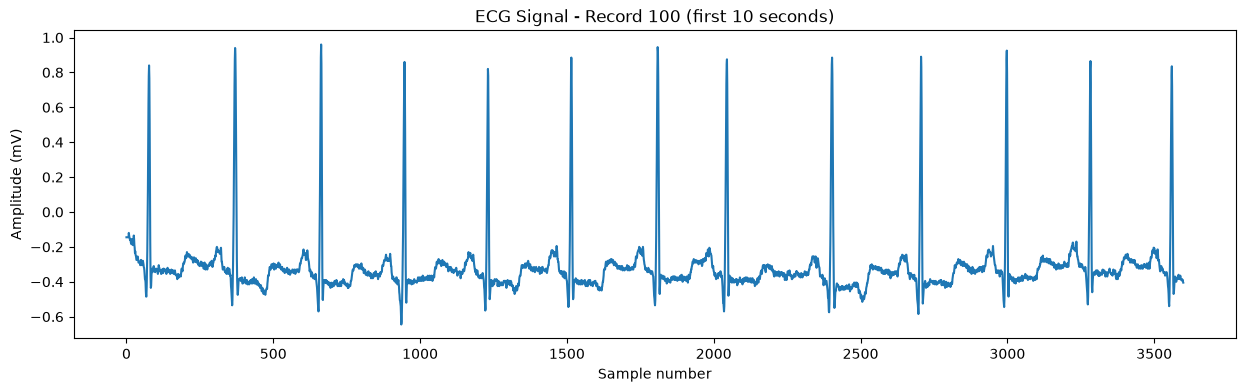

In [2]:
import wfdb
import matplotlib.pyplot as plt

# Download record 100 from the MIT-BIH Arrhythmia Database (auto-fetches from PhysioNet)
record = wfdb.rdrecord('100', pn_dir='mitdb')

# Print basic info about the record
print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs, "Hz")
print("Signal names:", record.sig_name)

# Plot the first 10 seconds of the first channel
fs = record.fs
duration_sec = 10
samples = fs * duration_sec

plt.figure(figsize=(15, 4))
plt.plot(record.p_signal[:samples, 0])
plt.title("ECG Signal - Record 100 (first 10 seconds)")
plt.xlabel("Sample number")
plt.ylabel("Amplitude (mV)")
plt.show()

Number of R-peaks detected: 2273


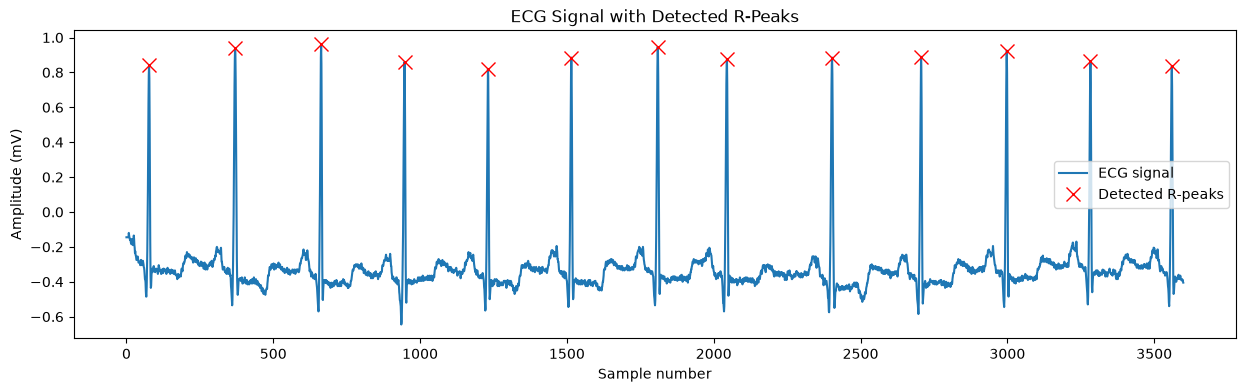

In [3]:
from scipy.signal import find_peaks
import numpy as np

# Get the full signal (channel 0 = MLII lead)
signal = record.p_signal[:, 0]

# Find peaks: R-peaks are tall and spaced apart (a real heart can't beat faster than ~40 times per 10 sec)
peaks, properties = find_peaks(signal, height=0.5, distance=fs*0.4)

print(f"Number of R-peaks detected: {len(peaks)}")

# Plot again, this time with detected peaks marked
plt.figure(figsize=(15, 4))
plt.plot(signal[:samples], label="ECG signal")
peaks_in_window = peaks[peaks < samples]
plt.plot(peaks_in_window, signal[peaks_in_window], "rx", markersize=10, label="Detected R-peaks")
plt.title("ECG Signal with Detected R-Peaks")
plt.xlabel("Sample number")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.show()

Average heart rate: 75.8 bpm
Min heart rate: 58.4 bpm
Max heart rate: 114.9 bpm


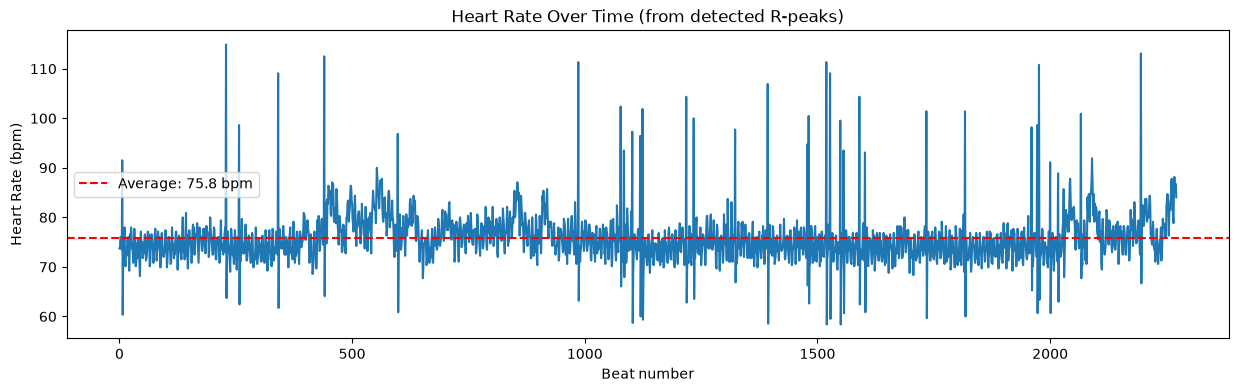

In [4]:
# Calculate heart rate from R-R intervals (time between consecutive peaks)
rr_intervals = np.diff(peaks) / fs  # convert sample gaps to seconds
heart_rates = 60 / rr_intervals      # beats per minute

print(f"Average heart rate: {heart_rates.mean():.1f} bpm")
print(f"Min heart rate: {heart_rates.min():.1f} bpm")
print(f"Max heart rate: {heart_rates.max():.1f} bpm")

# Plot heart rate over time
plt.figure(figsize=(15, 4))
plt.plot(heart_rates)
plt.title("Heart Rate Over Time (from detected R-peaks)")
plt.xlabel("Beat number")
plt.ylabel("Heart Rate (bpm)")
plt.axhline(y=heart_rates.mean(), color='r', linestyle='--', label=f'Average: {heart_rates.mean():.1f} bpm')
plt.legend()
plt.show()

In [5]:
# Load a record known to have arrhythmias, along with its expert annotations
record2 = wfdb.rdrecord('200', pn_dir='mitdb')
annotation = wfdb.rdann('200', 'atr', pn_dir='mitdb')

signal2 = record2.p_signal[:, 0]
fs2 = record2.fs

print(f"Record 200 loaded: {len(signal2)} samples")
print(f"Number of expert-annotated beats: {len(annotation.sample)}")
print(f"Beat types present: {set(annotation.symbol)}")

# Run our same peak detector on this new record
peaks2, _ = find_peaks(signal2, height=0.5, distance=fs2*0.4)
print(f"Number of R-peaks WE detected: {len(peaks2)}")

Record 200 loaded: 650000 samples
Number of expert-annotated beats: 2792
Beat types present: {'V', '+', 'A', 'N', '~', 'F'}
Number of R-peaks WE detected: 2523


In [6]:
# Compare our detected peaks against expert annotations more rigorously
# Match each of our detected peaks to the nearest true annotation within a small tolerance window

tolerance = int(0.05 * fs2)  # 50ms tolerance, standard for ECG peak matching

true_peaks = annotation.sample
matched = 0

for true_peak in true_peaks:
    # check if any of our detected peaks falls within tolerance of this true peak
    if np.any(np.abs(peaks2 - true_peak) <= tolerance):
        matched += 1

missed = len(true_peaks) - matched
false_positives = len(peaks2) - matched

print(f"True beats: {len(true_peaks)}")
print(f"Correctly matched: {matched}")
print(f"Missed beats (false negatives): {missed}")
print(f"Extra detections (false positives): {false_positives}")
print(f"Sensitivity (recall): {matched/len(true_peaks)*100:.1f}%")

True beats: 2792
Correctly matched: 1849
Missed beats (false negatives): 943
Extra detections (false positives): 674
Sensitivity (recall): 66.2%


In [7]:
print("Record 100 signal stats:")
print(f"  Min: {signal.min():.3f}, Max: {signal.max():.3f}, Mean: {signal.mean():.3f}")

print("\nRecord 200 signal stats:")
print(f"  Min: {signal2.min():.3f}, Max: {signal2.max():.3f}, Mean: {signal2.mean():.3f}")

Record 100 signal stats:
  Min: -2.715, Max: 1.435, Mean: -0.306

Record 200 signal stats:
  Min: -2.695, Max: 2.380, Mean: -0.105


In [8]:
!pip install neurokit2

   ---------------------------------------- 0.0/688.9 kB ? eta -:--:--
   ---------------------------------------- 688.9/688.9 kB 5.0 MB/s  0:00:00
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.1 MB 4.4 MB/s eta 0:00:03
   ----- ---------------------------------- 1.6/11.1 MB 4.1 MB/s eta 0:00:03
   --------- ------------------------------ 2.6/11.1 MB 4.1 MB/s eta 0:00:03
   ------------ --------------------------- 3.4/11.1 MB 3.9 MB/s eta 0:00:02
   -------------- ------------------------- 3.9/11.1 MB 3.7 MB/s eta 0:00:02
   ----------------- ---------------------- 5.0/11.1 MB 4.0 MB/s eta 0:00:02
   -------------------- ------------------- 5.8/11.1 MB 4.0 MB/s eta 0:00:02
   ----------------------- ---------------- 6.6/11.1 MB 4.0 MB/s eta 0:00:02
   -------------------------- ------------- 7.3/11.1 MB 4.0 MB/s eta 0:00:01
   ------------------------------ --------- 8.4/11.1 MB 3.9 MB/s eta 0:00:01
   ---------

  You can safely remove it manually.


In [9]:
import neurokit2 as nk

# Process the signal with neurokit2's built-in ECG pipeline
signals, info = nk.ecg_process(signal2, sampling_rate=fs2)

# Extract the R-peak locations it found
nk_peaks = info["ECG_R_Peaks"]

print(f"neurokit2 detected: {len(nk_peaks)} R-peaks")
print(f"True beats (expert annotated): {len(true_peaks)}")

# Re-run the same sensitivity check as before, using neurokit2's peaks instead
matched_nk = 0
for true_peak in true_peaks:
    if np.any(np.abs(nk_peaks - true_peak) <= tolerance):
        matched_nk += 1

missed_nk = len(true_peaks) - matched_nk
false_positives_nk = len(nk_peaks) - matched_nk

print(f"Correctly matched: {matched_nk}")
print(f"Missed beats: {missed_nk}")
print(f"Extra detections: {false_positives_nk}")
print(f"Sensitivity (recall): {matched_nk/len(true_peaks)*100:.1f}%")

neurokit2 detected: 2609 R-peaks
True beats (expert annotated): 2792
Correctly matched: 2187
Missed beats: 605
Extra detections: 422
Sensitivity (recall): 78.3%


In [10]:
# Filter to only actual beat annotations (exclude rhythm/noise markers)
non_beat_symbols = ['+', '~', '|', '"', 'x']
beat_mask = [sym not in non_beat_symbols for sym in annotation.symbol]
true_beats_only = annotation.sample[beat_mask]

print(f"Actual true beats (filtered): {len(true_beats_only)}")

# Re-check neurokit2's sensitivity against the CORRECT true beat count
matched_clean = 0
for tb in true_beats_only:
    if np.any(np.abs(nk_peaks - tb) <= tolerance):
        matched_clean += 1

print(f"Correctly matched: {matched_clean}")
print(f"Sensitivity (recall): {matched_clean/len(true_beats_only)*100:.1f}%")

Actual true beats (filtered): 2601
Correctly matched: 2184
Sensitivity (recall): 84.0%


In [11]:
# Try a specific, well-established detection method within neurokit2
_, rpeaks_pt = nk.ecg_peaks(signal2, sampling_rate=fs2, method="pantompkins1985")
pt_peaks = rpeaks_pt["ECG_R_Peaks"]

matched_pt = 0
for tb in true_beats_only:
    if np.any(np.abs(pt_peaks - tb) <= tolerance):
        matched_pt += 1

print(f"Pan-Tompkins method detected: {len(pt_peaks)} peaks")
print(f"Correctly matched: {matched_pt}")
print(f"Sensitivity (recall): {matched_pt/len(true_beats_only)*100:.1f}%")

Pan-Tompkins method detected: 2641 peaks
Correctly matched: 2014
Sensitivity (recall): 77.4%


In [12]:
import pandas as pd

def extract_features(signal, peaks, fs):
    features = []
    for i in range(1, len(peaks) - 1):  # skip first/last (need neighbors)
        pre_rr = (peaks[i] - peaks[i-1]) / fs      # time since previous beat
        post_rr = (peaks[i+1] - peaks[i]) / fs     # time to next beat
        amplitude = signal[peaks[i]]               # peak height
        
        # simple beat width: samples around peak that stay above half its height
        window = signal[max(0, peaks[i]-20):peaks[i]+20]
        width = np.sum(window > amplitude * 0.5) / fs
        
        features.append([pre_rr, post_rr, amplitude, width])
    return np.array(features)

# Use record 200's neurokit2-detected peaks (the 84% sensitivity ones)
X = extract_features(signal2, nk_peaks, fs2)
print(f"Extracted features for {len(X)} beats")
print("Sample row:", X[0])

Extracted features for 2607 beats
Sample row: [0.76666667 0.51944444 1.06       0.02777778]


In [13]:
def get_labels(peaks, true_beats, true_symbols, tolerance):
    labels = []
    for i in range(1, len(peaks) - 1):  # match the same range used in extract_features
        peak = peaks[i]
        # find the closest true annotation to this detected peak
        distances = np.abs(true_beats - peak)
        closest_idx = np.argmin(distances)
        
        if distances[closest_idx] <= tolerance:
            symbol = true_symbols[closest_idx]
            label = 0 if symbol == 'N' else 1   # 0 = Normal, 1 = Abnormal
        else:
            label = -1  # no matching true beat found (detection error) — we'll drop these
        labels.append(label)
    return np.array(labels)

true_symbols_arr = np.array(annotation.symbol)
y = get_labels(nk_peaks, true_beats_only, true_symbols_arr[beat_mask], tolerance)

# Drop rows where we couldn't find a matching true beat
valid = y != -1
X_clean = X[valid]
y_clean = y[valid]

print(f"Total labeled beats: {len(y_clean)}")
print(f"Normal beats: {np.sum(y_clean == 0)}")
print(f"Abnormal beats: {np.sum(y_clean == 1)}")

Total labeled beats: 2182
Normal beats: 1579
Abnormal beats: 603


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Split into train/test sets (80/20), stratified to preserve class balance in both
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

# class_weight='balanced' tells the model to account for the imbalance we just saw
clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98       316
    Abnormal       0.93      0.97      0.95       121

    accuracy                           0.97       437
   macro avg       0.96      0.97      0.96       437
weighted avg       0.97      0.97      0.97       437

Confusion Matrix:
[[307   9]
 [  4 117]]
